Charger les bibliothèques et réglages communs

In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

Charger des bibliothèques supplémentaires

In [17]:
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

La première chose à faire dans toute tâche d’analyse de données est de tracer les données. Les graphiques permettent de visualiser de nombreuses caractéristiques des données, notamment les motifs, les observations inhabituelles, les changements dans le temps et les relations entre variables. Les caractéristiques observées dans les graphiques des données doivent ensuite être intégrées, autant que possible, dans les méthodes de prévision à utiliser. Tout comme le type de données détermine la méthode de prévision à utiliser, il détermine aussi quels graphiques sont appropriés. Mais avant de produire des graphiques, nous devons configurer nos séries temporelles en Python

1)Objets *DataFrame*

Une série temporelle consiste en une séquence d’observations numériques accompagnées d’informations sur le moment où ces chiffres ont été enregistrés. Parfois, une observation primaire est accompagnée de données apparentées appelées covariables ou variables exogènes. Ces données sont généralement stockées dans une structure de données tabulaire bidimensionnelle appelée dataframe. En Python, les tables sont souvent créées sous forme d’objets pandas, ou plus récemment, comme objets Polars. Si la trame de données prend trop de temps ou de mémoire à être traitée, des implémentations de dataframes distribuées telles que Dask, Spark ou Ray peuvent également être utilisées. Nous allons nous concentrer sur les pandas

## Index et colonnes

Un `DataFrame` Pandas peut être considéré comme un tableau de valeurs disposées selon deux axes : l’**index**, qui identifie les lignes, et les **colonnes**, qui identifient les variables.

Par exemple, supposons que vous ayez des observations annuelles pour certaines années récentes :

| **Index** | **Année** | **Observation** |
|----------:|----------:|----------------:|
| **0**     | 2015      | 123             |
| **1**     | 2016      | 39              |
| **2**     | 2017      | 78              |
| **3**     | 2018      | 52              |
| **4**     | 2019      | 110             |

Nous pouvons stocker ces informations sous la forme d’un `DataFrame` à l’aide du constructeur `pd.DataFrame()` 

In [9]:
df = pd.DataFrame({
    "Year": list(range(2015, 2020)),
    "Observation": [123, 39, 78, 52, 110],
})

En inspectant les propriétés de la trame, on peut voir que l’index va de `0` jusqu’à `5` (sans inclure `5`) et que les colonnes incluent `Year` et `Observation`.

On peut vérifier ces informations à l’aide des attributs suivants :

In [10]:
print(df.index)
print(df.columns)

RangeIndex(start=0, stop=5, step=1)
Index(['Year', 'Observation'], dtype='str')


Les types de données sont suivis sur une base de colonne par colonne :

In [11]:
df.dtypes

Year           int64
Observation    int64
dtype: object

Les colonnes individuelles d’un `DataFrame` Pandas peuvent être accessibles et manipulées sous forme d’objets `Series`

In [12]:
print(type(df["Year"]))
print(df["Year"])

<class 'pandas.Series'>
0    2015
1    2016
2    2017
3    2018
4    2019
Name: Year, dtype: int64


L’index d’un `DataFrame` peut être remplacé par l’une de ses colonnes en utilisant la méthode `.set_index()`

In [13]:
year_df = df.set_index("Year")
year_df

,Observation
Year,
2015,123
2016,39
2017,78
2018,52
2019,110


## Horodatages et périodes

Les observations de séries temporelles peuvent être associées à des **instants dans le temps** ou à des **périodes de temps**. Pandas prend en charge ces deux concepts à travers les classes `pd.Timestamp` et `pd.Period`, respectivement.

In [14]:
print(repr(pd.Timestamp("2020-01")))
print(repr(pd.Period("2020-01")))

Timestamp('2020-01-01 00:00:00')
Period('2020-01', 'M')


Pandas propose de nombreux utilitaires pour convertir des chaînes de texte en représentations temporelles ou en périodes dédiées.

En interne, les horodatages sont stockés par défaut avec une précision de **nanoseconde**. Cependant, pour simplifier leur utilisation, une spécification partielle suffit pour désigner le premier instant correspondant à l’entrée.

Pour les périodes, la même logique est utilisée : Pandas identifie le début de l’intervalle de temps et déduit sa durée à partir de la précision fournie, sauf si la **fréquence** est explicitement indiquée avec l’argument `freq=`.

In [16]:
print(repr(pd.Timestamp("2020")))
print(repr(pd.Timestamp("2020-01-01 12:34")))
print(repr(pd.Period("2020-01-01")))
print(repr(pd.Period("2020-01-01", freq="M")))

Timestamp('2020-01-01 00:00:00')
Timestamp('2020-01-01 12:34:00')
Period('2020-01-01', 'D')
Period('2020-01', 'M')


Les séquences d’horodatages peuvent être construites facilement à l’aide de `pd.to_datetime()` ou `pd.date_range()`.

In [18]:
ts_few = pd.to_datetime(["2020-01-01", "2020-01-02", "2020-01-03"])
ts_range = pd.date_range("2020-01-01", "2020-01-02", freq="8h")
print(ts_few)
print(ts_range)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[us]', freq='8h')


Les méthodes `.to_period()` et `.to_timestamp()` permettent d’effectuer des conversions entre les **horodatages** et les **périodes**.

La méthode `.to_period()` déduit automatiquement la fréquence de la période, sauf si l’argument `freq=` est explicitement spécifié.


In [19]:
print(ts_range.to_period())
print(ts_range.to_period(freq="D"))
print(ts_range.to_period(freq="W"))
print(ts_range.to_period().to_timestamp())

PeriodIndex(['2020-01-01 00:00', '2020-01-01 08:00', '2020-01-01 16:00',
             '2020-01-02 00:00'],
            dtype='period[8h]')
PeriodIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-02'], dtype='period[D]')
PeriodIndex(['2019-12-30/2020-01-05', '2019-12-30/2020-01-05',
             '2019-12-30/2020-01-05', '2019-12-30/2020-01-05'],
            dtype='period[W-SUN]')
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[us]', freq='8h')


Notez que cela indique les semaines commençant lundi et se terminant dimanche.W-SUN

Les horodatages et les heures de début des périodes peuvent être convertis en chaînes de caractères avec une mise en page personnalisée en utilisant :  .strftime()

In [21]:
print(ts_few.strftime("%m/%d/%Y"))
print(ts_range.to_period().strftime("%Y %b ~ %H:%M"))

Index(['01/01/2020', '01/02/2020', '01/03/2020'], dtype='str')
Index(['2020 Jan ~ 00:00', '2020 Jan ~ 08:00', '2020 Jan ~ 16:00',
       '2020 Jan ~ 00:00'],
      dtype='str')


Pandas convertit automatiquement entre les types `Timestamp`, `Period`, `Series` et `Index` selon les besoins lorsque ces séquences sont utilisées comme données ou comme index dans un `DataFrame`.

Pour les objets de type `Series`, les méthodes et attributs liés aux dates et aux heures sont accessibles à travers l’accesseur `.dt`.


In [24]:
df = pd.DataFrame({"ts": ts_few})

df = df.assign(
    periode=df["ts"].dt.to_period(),
    annee=df["ts"].dt.year,
    date_texte=df["ts"].dt.strftime("%A, %B %#d"),
).set_index("ts")

df


,periode,annee,date_texte
ts,,,
2020-01-01,2020-01-01,2020,"Wednesday, January 1"
2020-01-02,2020-01-02,2020,"Thursday, January 2"
2020-01-03,2020-01-03,2020,"Friday, January 3"


Nous stockons généralement les temps d’observation sous forme d’horodatages. Dans certains cas, nous utilisons des types entiers tels que l’année ou le nombre de jours écoulés depuis une date de référence.

Habituellement, les données temporelles sont stockées dans une colonne, souvent appelée `date` ou `timestamp`. Cependant, il arrive que nous utilisions `set_index()` pour définir cette colonne comme index et ainsi accéder à certaines fonctionnalités de Pandas.

### Variables clés

Un `DataFrame` permet de stocker plusieurs séries temporelles dans un seul objet. Supposons que vous soyez intéressé par un jeu de données contenant les meilleurs temps de course pour les épreuves féminines et masculines sur piste aux Jeux Olympiques, du 100 m au 10 000 m.

In [6]:
data_olympic = pd.read_csv("data/olympic_running_unparsed.csv")
data_olympic.head(10)

,Year,Length,Sex,Time
0,1896,100,men,12.0
1,1900,100,men,11.0
2,1904,100,men,11.0
3,1908,100,men,10.8
4,1912,100,men,10.8
5,1916,100,men,NaN
6,1920,100,men,10.8
7,1924,100,men,10.6
8,1928,100,men,10.8
9,1932,100,men,10.3


Cela contient **312 lignes et 4 colonnes**. Les données sont enregistrées tous les quatre ans, et cette série `DataFrame` contient **14 séries temporelles distinctes**.

Un aperçu des **10 premières observations** est également présenté, dans lequel on peut voir qu’une valeur manquante apparaît en **1916**. Cela s’explique par le fait que les Jeux olympiques n’ont pas eu lieu pendant la **Première Guerre mondiale**.

Les 14 séries temporelles sont identifiées de manière unique par les variables clés `Length` et `Sex`.

La méthode `.unique()` peut être utilisée pour afficher les catégories distinctes d’une variable sous forme de tableau :

In [7]:
data_olympic["Sex"].unique()

array(['men', 'women'], dtype=object)

La méthode `.drop_duplicates()` peut être utilisée pour afficher les valeurs distinctes d’une `Series` ou les combinaisons distinctes de valeurs dans plusieurs `Series`.

In [8]:
data_olympic[["Sex", "Length"]].drop_duplicates()

,Sex,Length
0,men,100
31,women,100
54,men,200
84,women,200
102,men,400
133,women,400
147,men,800
178,women,800
201,men,1500
232,women,1500


### Travailler avec des trames de données de séries temporelles

Nous pouvons manipuler des objets `DataFrame` à l’aide de méthodes Pandas telles que `.assign()`, `.rename()`, `.drop()`, `.groupby()` et `.agg()`, ainsi que des opérations de sélection et de tranchage telles que `[]` et `.loc[]`.

Pour illustrer cela, nous utiliserons le jeu de données `PBS`, qui contient des données sur les ventes de produits pharmaceutiques en Australie.

In [9]:
pbs = (
    pd.read_csv("data/PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)
pbs

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


Celle-ci contient des données mensuelles sur les prescriptions de Medicare Australia de **juillet 1991 à juin 2008**. Ces dernières sont classées selon différents types de concessions et selon les indices de produits chimiques thérapeutiques anatomiques (**ATC**).

Pour cet exemple, nous nous intéressons à la série chronologique `Cost`, qui représente le **coût total des prescriptions en dollars australiens**.

Nous avons déjà utilisé `[]` pour sélectionner un sous-ensemble des colonnes disponibles. Nous pouvons également utiliser `.loc[]` pour extraire les lignes correspondant aux prescriptions de la catégorie **A10**.

In [10]:
a10 = pbs.loc[pbs["ATC2"] == "A10"]
a10

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,A,A10,89733,2.093e+06
1525,1991-08-01,Concessional,Co-payments,A,A10,77101,1.796e+06
1526,1991-09-01,Concessional,Co-payments,A,A10,76255,1.777e+06
1527,1991-10-01,Concessional,Co-payments,A,A10,78681,1.849e+06
1528,1991-11-01,Concessional,Co-payments,A,A10,70554,1.686e+06
...,...,...,...,...,...,...,...
52339,2008-02-01,General,Safety net,A,A10,10869,5.307e+05
52340,2008-03-01,General,Safety net,A,A10,1119,5.177e+04
52341,2008-04-01,General,Safety net,A,A10,721,3.629e+04
52342,2008-05-01,General,Safety net,A,A10,1947,1.012e+05


Ensuite, nous pouvons simplifier l’objet résultant en utilisant `.drop()` afin de supprimer les colonnes qui ne sont pas nécessaires pour l’analyse ultérieure.

In [11]:
a10 = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
)
a10

,Month,Concession,Type,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,89733,2.093e+06
1525,1991-08-01,Concessional,Co-payments,77101,1.796e+06
1526,1991-09-01,Concessional,Co-payments,76255,1.777e+06
1527,1991-10-01,Concessional,Co-payments,78681,1.849e+06
1528,1991-11-01,Concessional,Co-payments,70554,1.686e+06
...,...,...,...,...,...
52339,2008-02-01,General,Safety net,10869,5.307e+05
52340,2008-03-01,General,Safety net,1119,5.177e+04
52341,2008-04-01,General,Safety net,721,3.629e+04
52342,2008-05-01,General,Safety net,1947,1.012e+05


Une autre méthode utile est `.agg()`, qui permet d’agréger les données sur l’ensemble des lignes ou, lorsqu’elle est utilisée avec `.groupby()`, au sein de groupes définis par une ou plusieurs colonnes du `DataFrame`.

Par exemple, nous pouvons souhaiter calculer le **coût total par mois**, indépendamment des valeurs de `Concession` ou de `Type`.

In [12]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .rename(columns={"Cost": "TotalC"})
)
total_cost_df

,Month,TotalC
0,1991-07-01,3.527e+06
1,1991-08-01,3.181e+06
2,1991-09-01,3.252e+06
3,1991-10-01,3.611e+06
4,1991-11-01,3.566e+06
...,...,...
199,2008-02-01,2.165e+07
200,2008-03-01,1.826e+07
201,2008-04-01,2.311e+07
202,2008-05-01,2.291e+07


La nouvelle colonne, que nous avons nommée `TotalC` en utilisant la méthode `.rename()`, représente la somme de toutes les valeurs de `Cost` pour chaque mois.

Nous pouvons créer ou mettre à jour des colonnes à l’aide de la méthode `.assign()`. Ici, nous supprimons l’opération de renommage et convertissons les valeurs de `Cost` de dollars en **millions de dollars**.

In [13]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .assign(Cost=lambda x: (x["Cost"] / 1e6).round(2))
)
total_cost_df

,Month,Cost
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


Dans cette opération, nous démontrons également l’utilisation d’une fonction anonyme, généralement définie avec `lambda`. Les fonctions `lambda` sont souvent utilisées avec `.assign()`, `.loc[]` et d’autres méthodes pour accéder ou transformer les données des colonnes, même lorsque le `DataFrame` d’entrée n’est pas associé à un nom de variable.

### Travailler avec des fichiers CSV

Les données réelles sont disponibles dans différents formats de stockage, tels que les feuilles de calcul, les bases de données, ainsi que divers types de fichiers texte et binaires. Presque toutes les données de ce livre sont stockées dans des fichiers **CSV**.

La première étape pour travailler avec des données de séries temporelles consiste à charger les données dans un `DataFrame` et à identifier la **colonne temporelle** ainsi que les **variables clés**.

Par exemple, supposons que nous ayons les données trimestrielles suivantes stockées dans un fichier CSV (seules les 10 premières lignes sont affichées).

Cet ensemble de données fournit des informations sur la **population carcérale en Australie**, désagrégées selon l’État, le genre, le statut légal et le statut autochtone.

> **ATSI** signifie *Aborigène ou Insulaire du détroit de Torres*.

Nous pouvons lire (ou charger) le fichier CSV dans un `DataFrame` en appelant la fonction `pd.read_csv()`.

En définissant `parse_dates=["Date"]`, nous nous assurons que la colonne `Date` est automatiquement convertie en **horodatage (`Timestamp`)** associé à chaque observation.

Dans ce cas, les données sont **trimestrielles**, et la colonne `Date` doit être interprétée comme la **première date du dernier mois de chaque trimestre**.

In [14]:
prison = (
    pd.read_csv("data/prison_population.csv", parse_dates=["Date"])
    .rename(columns={"Date": "Quarter"})
    .sort_values(by=["State", "Gender", "Legal", "Indigenous"])
)
prison

,Quarter,State,Gender,Legal,Indigenous,Count
0,2005-03-01,ACT,Female,Remanded,ATSI,0
64,2005-06-01,ACT,Female,Remanded,ATSI,1
128,2005-09-01,ACT,Female,Remanded,ATSI,0
192,2005-12-01,ACT,Female,Remanded,ATSI,0
256,2006-03-01,ACT,Female,Remanded,ATSI,1
...,...,...,...,...,...,...
2815,2015-12-01,WA,Male,Sentenced,Non-ATSI,2503
2879,2016-03-01,WA,Male,Sentenced,Non-ATSI,2488
2943,2016-06-01,WA,Male,Sentenced,Non-ATSI,2539
3007,2016-09-01,WA,Male,Sentenced,Non-ATSI,2608


Ce `DataFrame` contient **64 séries temporelles uniques**, correspondant aux combinaisons uniques de **8 États**, **2 genres**, **2 statuts juridiques** et **2 statuts autochtones**.

Chacune de ces séries comporte **48 observations**, allant du **premier trimestre 2005 au quatrième trimestre 2016**.

Pour qu’un `DataFrame` de séries temporelles soit valide pour la prévision ou pour une autre analyse, chaque série temporelle distincte doit être identifiée par une **combinaison unique de variables clés**. Dans ce cas, les variables clés sont les colonnes `State`, `Gender`, `Legal` et `Indigenous`.

Nous pouvons également écrire des `DataFrame` dans des fichiers CSV en utilisant la méthode `.to_csv()`.

Par exemple, nous pouvons enregistrer le `DataFrame` `total_cost_df` dans un fichier CSV :

```python
total_cost_df.to_csv("total_cost.csv", index=False)

Assurez-vous de spécifier le bon chemin pour sauvegarder le fichier dans votre propre dossier de travail si vous exécutez ce code.

Si vous n’êtes pas sûr du répertoire de travail actuel, vous pouvez le vérifier à l’aide de `os.getcwd()`.

### La période saisonnière

Les **saisonnalités** sont particulièrement importantes pour l’analyse des séries temporelles. Certains graphiques et certains modèles reposent sur la présence d’une période saisonnière répétitive dans les données.

La **période saisonnière** correspond au nombre d’observations nécessaires avant qu’un schéma saisonnier ne se répète. Certains algorithmes peuvent détecter automatiquement cette période à partir d’un index temporel ou d’une colonne de dates.

Quelques périodes saisonnières courantes pour différents intervalles de temps sont présentées dans le tableau ci-dessous :
|              | Minute | Heure | Jour  | Semaine | Année    |
|--------------|--------|-------|-------|---------|----------|
| Quarters     |        |       |       |         | 4        |
| Mois         |        |       |       |         | 12       |
| Semaines     |        |       |       |         | 52       |
| Jours        |        |       |       | 7       | 365.25   |
| Horaires     |        |       | 24    | 168     | 8766     |
| Procès-verbal|        | 60    | 1440  | 10080   | 525960   |
| Secondes     | 60     | 3600  | 86400 | 604800  | 31557600 |


Pour les données trimestrielles, mensuelles et hebdomadaires, il n’y a qu’une seule période saisonnière : le nombre d’observations au cours de chaque année.

Notons qu’en réalité, il n’y a pas exactement `52` semaines dans une année, mais en moyenne :

`365.25 / 7 = 52.18`

Cette valeur moyenne permet de tenir compte des années bissextiles qui surviennent tous les quatre ans. L’approximation des périodes saisonnières par des nombres entiers peut être utile, car de nombreux termes saisonniers dans les modèles ne prennent en charge que des périodes saisonnières entières.

Si les données sont observées plus d’une fois par semaine, il y a souvent plus d’un schéma saisonnier dans les données. Par exemple, des données avec des observations quotidiennes peuvent présenter une saisonnalité hebdomadaire (`période = 7`) ou annuelle (`période = 365.25`).

De même, les données observées chaque minute peuvent présenter plusieurs schémas saisonniers :

- horaire (`période = 60`) ;
- quotidien (`période = 24 × 60 = 1 440`) ;
- hebdomadaire (`période = 24 × 60 × 7 = 10 080`) ;
- annuel (`période = 24 × 60 × 365.25 = 525 960`).

Des schémas saisonniers plus complexes et inhabituels peuvent être analysés à l’aide de modèles spécialisés disponibles dans le package `statsforecast`, tels que `MSTL`, `MFLES`, `TBATS` et `BATS`.

## Graphiques temporels

Pour les données de séries temporelles, le graphique le plus évident pour commencer est un **graphique temporel**. Les observations sont représentées en fonction du moment où elles ont été observées, et les observations consécutives sont reliées par des lignes droites.

Il présente le nombre hebdomadaire de passagers en classe économique sur les vols de la compagnie aérienne Ansett entre les deux plus grandes villes d’Australie, **Melbourne et Sydney**.

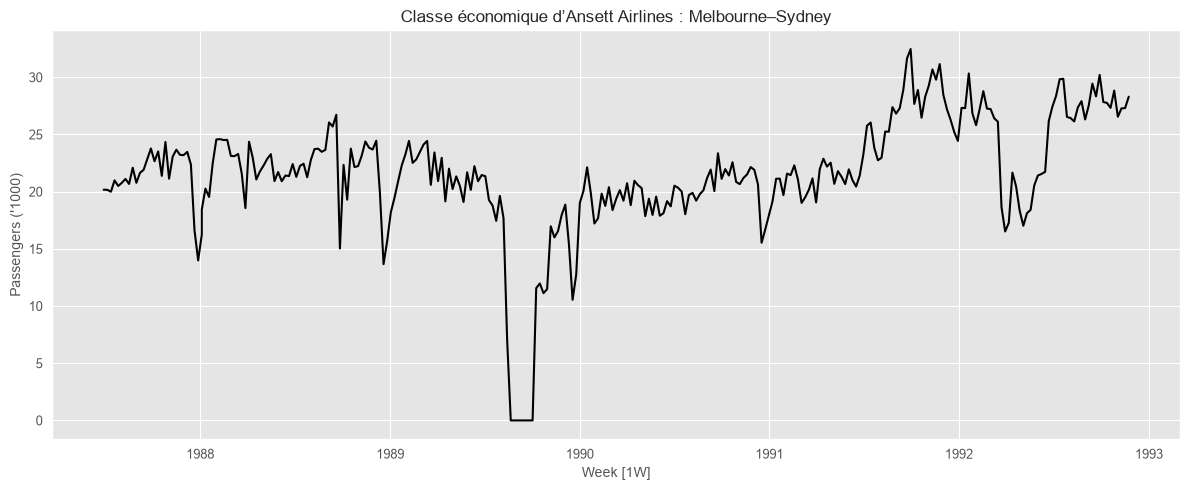

In [26]:
# Charger et préparer les données
melsyd_economy = (
    pd.read_csv("data/ansett.csv", parse_dates=["ds"])
    .loc[lambda x: 
         (x["Airports"] == "MEL-SYD") &
         (x["Class"] == "Economy")
    ]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
)

# Créer le graphique
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    melsyd_economy["ds"],
    melsyd_economy["y"]
)

ax.set_xlabel("Week [1W]")
ax.set_ylabel("Passengers ('1000)")
ax.set_title("Classe économique d’Ansett Airlines : Melbourne–Sydney")

ax.grid(True)
fig.tight_layout()

# Afficher avec pyplot
plt.show()

Pour la création de graphiques de séries temporelles, nous utilisons souvent la fonction `plot_series()` de la bibliothèque `utilsforecast`. Cette fonction nécessite les paramètres suivants :

- `df` : DataFrame d’entrée (alias Pandas DataFrame).
- `id_col` : colonne d’identification de la série (également appelée identifiant unique).
- `time_col` : colonne contenant les horodatages (également appelée index temporel).
- `target_col` : colonne contenant la variable cible (également appelée mesure).

En organisant un `DataFrame` avec des noms de colonnes correspondant aux valeurs par défaut attendues par `utilsforecast` et les packages associés, nous pouvons simplifier l’appel de la fonction.

Pour plus de détails, consultez la [documentation de `utilsforecast`](https://nixtlaverse.nixtla.io/utilsforecast/index.html#plotting).

Cette représentation révèle plusieurs caractéristiques intéressantes :

- Il y a eu une période en 1989 où aucun passager n’a été transporté, en raison d’un conflit social.
- Une période de réduction de la capacité a eu lieu en 1992. Cela était dû à un essai au cours duquel certains sièges de la classe économique ont été remplacés par des sièges de classe affaires.
- Une forte augmentation du trafic de passagers a eu lieu au cours de la seconde moitié de 1991.
- De fortes baisses de la fréquentation sont observées au début de chaque année, en raison des effets saisonniers liés aux vacances.
- Le niveau de la série présente des fluctuations à long terme : il augmente en 1987, diminue en 1989, puis augmente à nouveau en 1990 et 1991.

Tout modèle devra prendre en compte l’ensemble de ces caractéristiques afin de prévoir efficacement la fréquentation future.

Une série temporelle plus simple est présentée à partir des données sauvegardées précédemment. Dans ce cas, comme nous avons déjà agrégé les données, nous n’avons qu’une seule série temporelle et nous ne disposons pas de colonne `unique_id`. Nous devons donc en créer une.

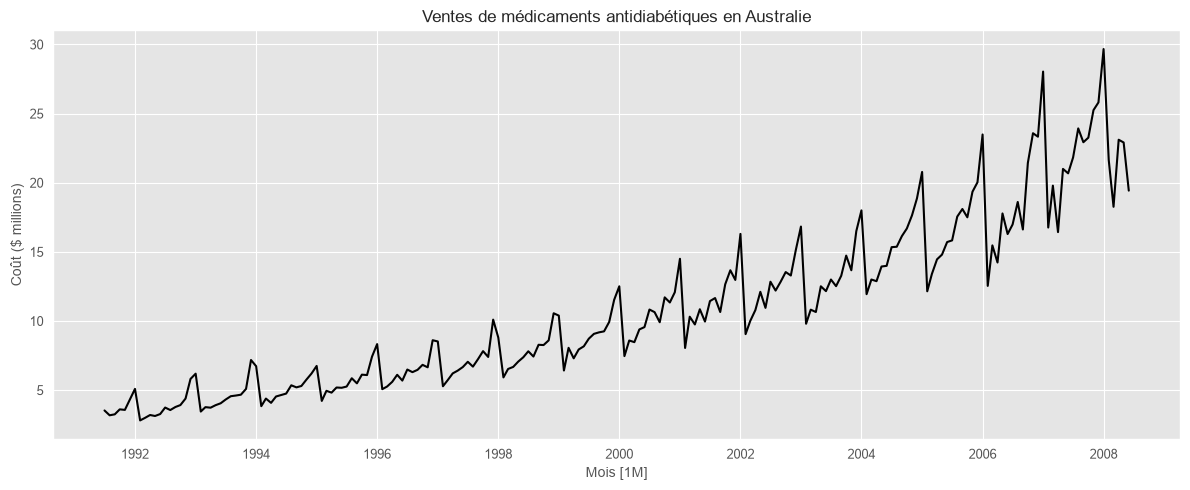

In [29]:
df = total_cost_df.assign(unique_id="total_cost")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["Month"], df["Cost"])

ax.set_xlabel("Mois [1M]")
ax.set_ylabel("Coût ($ millions)")
ax.set_title("Ventes de médicaments antidiabétiques en Australie")

ax.grid(True)
fig.tight_layout()

plt.show()

Ici, une **tendance clairement croissante** est observée. Il existe également un **fort schéma saisonnier**, dont l’amplitude augmente à mesure que le niveau de la série augmente.

La chute soudaine au début de chaque année est due à un **système de subventions gouvernementales** qui incite les patients à stocker des médicaments à la fin de l’année civile.

Toute prévision de cette série devrait donc prendre en compte le **schéma saisonnier**, ainsi que le fait que la **tendance évolue progressivement au fil du temps**.

## Schémas des séries temporelles

Pour décrire les séries temporelles, nous utilisons souvent des termes comme **tendance**, **saisonnalité** et **cycle**, qui nécessitent quelques précisions.

### Tendance

Une **tendance** existe lorsqu’il y a une augmentation ou une diminution à long terme des données. Elle n’est pas nécessairement linéaire. Parfois, nous parlons d’un **changement de direction** lorsque la série passe d’une tendance à la hausse à une tendance à la baisse, ou inversement.

On observe une tendance dans les données relatives aux ventes de médicaments antidiabétiques.

### Saisonnalité

Un schéma **saisonnier** se produit lorsqu’une série temporelle est influencée par des facteurs saisonniers tels que la **période de l’année**, le **jour de la semaine** ou l’**heure de la journée**.

La saisonnalité possède toujours une **période fixe et connue**. Les ventes mensuelles de médicaments antidiabétiques montrent une saisonnalité, due en partie aux variations du coût des médicaments à la fin de l’année civile.

> **Remarque :** une série temporelle peut présenter plusieurs schémas saisonniers.

### Cycle

Un **cycle** se produit lorsque les données présentent des fluctuations à la hausse et à la baisse qui ne suivent pas une fréquence fixe. Ces fluctuations sont généralement liées aux **conditions économiques** et sont souvent associées au **cycle économique**. La durée de ces fluctuations est généralement d’au moins deux ans.

Le comportement cyclique est souvent confondu avec le comportement saisonnier, mais ces deux phénomènes sont différents :

- si les fluctuations ne suivent **pas une fréquence fixe**, elles sont **cycliques** ;
- si la fréquence reste **constante** et est associée à un aspect du calendrier, le schéma est **saisonnier**.

En général, la durée moyenne des cycles est plus longue que celle des schémas saisonniers, et l’amplitude des cycles tend à être plus variable que celle des schémas saisonniers.

De nombreuses séries temporelles présentent simultanément une **tendance**, des **cycles** et une **saisonnalité**. Lors du choix d’une méthode de prévision, il faut d’abord identifier les caractéristiques présentes dans les données, puis choisir une méthode capable de représenter correctement ces différents schémas.

## Graphiques saisonniers

Un **graphique saisonnier** est similaire à un graphique temporel, à la différence que les données sont représentées en fonction des différentes **saisons** ou périodes au cours desquelles elles ont été observées.

Il permet notamment de comparer facilement le comportement de la série d’une année à l’autre et de mettre en évidence les **schémas saisonniers récurrents**.

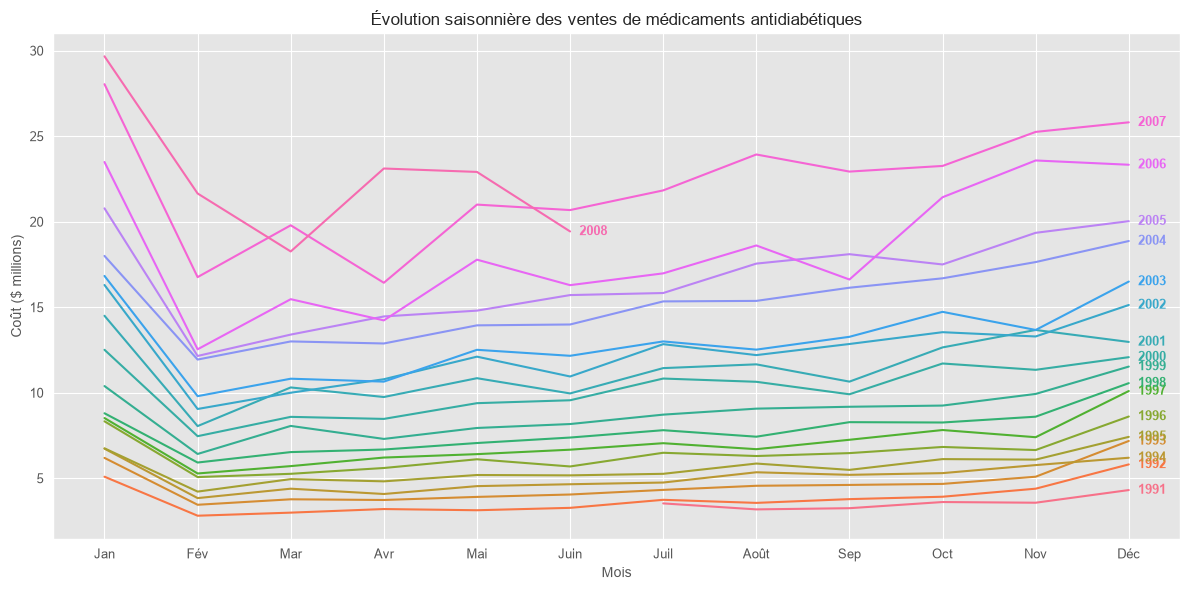

In [31]:
df = total_cost_df.assign(
    Mois_nom=total_cost_df["Month"].dt.strftime("%b"),
    Annee=total_cost_df["Month"].dt.year,
    Mois_num=total_cost_df["Month"].dt.month,
)

annees_uniques = df["Annee"].unique()

palette_annees = sns.color_palette(
    "husl",
    n_colors=len(annees_uniques)
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="Mois_num",
    y="Cost",
    hue="Annee",
    palette=palette_annees,
    legend=False,
    ax=ax
)

ax.set(
    title="Évolution saisonnière des ventes de médicaments antidiabétiques",
    xlabel="Mois",
    ylabel="Coût ($ millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
        "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
    ]
)

annee_min = annees_uniques.min()

for annee, subset in df.groupby("Annee"):
    x = subset["Mois_num"].iloc[-1] + 0.1
    y = subset["Cost"].iloc[-1]

    couleur = palette_annees[annee - annee_min]

    ax.text(
        x,
        y,
        str(annee),
        ha="left",
        va="center",
        fontsize=9,
        weight="bold",
        color=couleur
    )

fig.tight_layout()


Ce sont les mêmes données présentées précédemment, mais les observations de chaque année sont maintenant **superposées**.

Un graphique saisonnier permet de mettre plus clairement en évidence le **schéma saisonnier sous-jacent** et aide à identifier les années au cours desquelles ce schéma évolue.

On observe un **fort pic des ventes en janvier** de chaque année. Cela correspond probablement à des ventes réalisées à la fin du mois de décembre, lorsque les clients constituent des réserves avant la fin de l’année civile, mais qui ne sont enregistrées auprès du gouvernement qu’une ou deux semaines plus tard.

Le graphique montre également un **nombre exceptionnellement faible de ventes en mars 2008**, alors que la plupart des autres années présentent une augmentation entre février et mars.

Enfin, le faible nombre de ventes observé en **juin 2008** est probablement dû à un **comptage incomplet des ventes lors de la collecte des données**.

### Périodes saisonnières multiples

Lorsque les données présentent plusieurs schémas saisonniers, nous pouvons regrouper les données selon différentes périodes saisonnières et tracer les courbes correspondantes.

Les données `vic_elec` contiennent la demande d’électricité enregistrée toutes les demi-heures (`freq="30min"`) dans l’État de Victoria, en Australie. Elles présentent notamment des saisonnalités **quotidienne**, **hebdomadaire** et **annuelle**. :contentReference[oaicite:0]{index=0}

Nous pouvons ainsi représenter le schéma :

- **quotidien**, en regroupant les observations par jour ;
- **hebdomadaire**, en regroupant les observations par semaine ;
- **annuel**, en regroupant les observations par année.

Ces différentes représentations permettent de mieux comprendre les multiples schémas saisonniers présents dans les données.

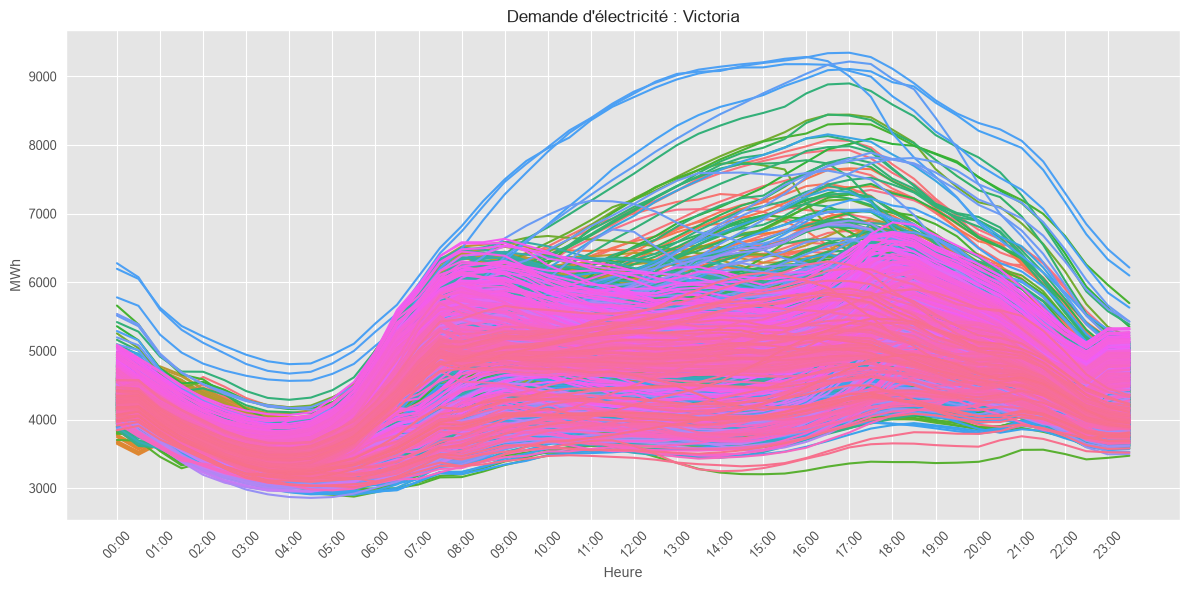

In [32]:
# Charger les données
vic_elec_df = pd.read_csv(
    "data/vic_elec.csv",
    parse_dates=["ds"]
)

# Sélectionner la demande d'électricité
vic_elec_demand = vic_elec_df[
    vic_elec_df["unique_id"] == "Demand"
]

# Préparer les données
df = vic_elec_demand.assign(
    heure_minute=lambda x: x["ds"].dt.strftime("%H:%M"),
    jour=lambda x: x["ds"].dt.date,
)

# Créer le graphique
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="heure_minute",
    y="y",
    hue="jour",
    palette="husl",
    legend=False,
    ax=ax
)

ax.set(
    title="Demande d'électricité : Victoria",
    xlabel="Heure",
    ylabel="MWh",
)

# Configurer les graduations de l'axe X
unique_ticks = df["heure_minute"].unique()

ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]

ax.set_xticks(
    ticks,
    labels=ticklabels,
    rotation=45
)

fig.tight_layout()

Graphique saisonnier montrant les tendances saisonnières quotidiennes de la demande d’électricité en Victoria.

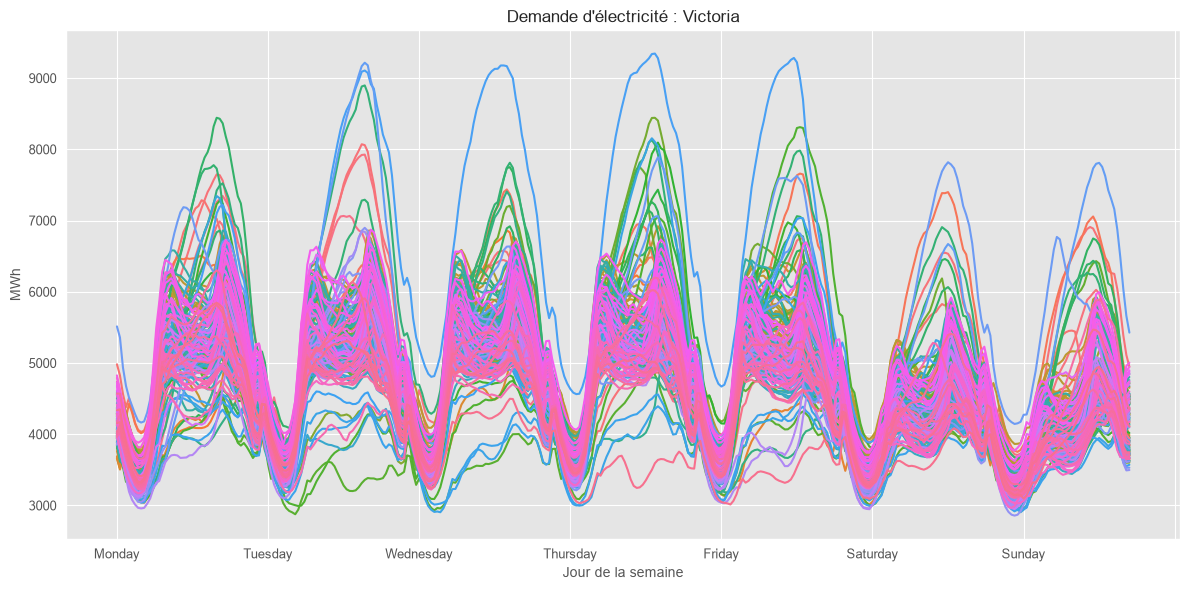

In [33]:
df = (
    vic_elec_demand
    .loc[
        lambda x: x["ds"].between(
            "2012-01-02",
            "2014-12-28 23:59"
        )
    ]
    .assign(
        jour_semaine=lambda x: x["ds"].dt.day_name(),
        semaine=lambda x: x["ds"].dt.to_period("W").dt.start_time,
    )
)

# Semaines uniques
semaines_uniques = df["semaine"].unique()

# Palette de couleurs
palette = sns.color_palette(
    "husl",
    n_colors=len(semaines_uniques)
)

color_map = dict(
    zip(semaines_uniques, palette)
)

# Création du graphique
fig, ax = plt.subplots(figsize=(12, 6))

for semaine, df_semaine in df.groupby("semaine"):
    df_semaine.plot(
        x="jour_semaine",
        y="y",
        ax=ax,
        color=color_map[semaine],
        legend=False
    )

ax.set(
    title="Demande d'électricité : Victoria",
    xlabel="Jour de la semaine",
    ylabel="MWh",
)

# Supprimer la légende si elle existe
if ax.get_legend() is not None:
    ax.get_legend().remove()

fig.tight_layout()

 Graphique saisonnier montrant les tendances saisonnières hebdomadaires de la demande d’électricité en Victoria

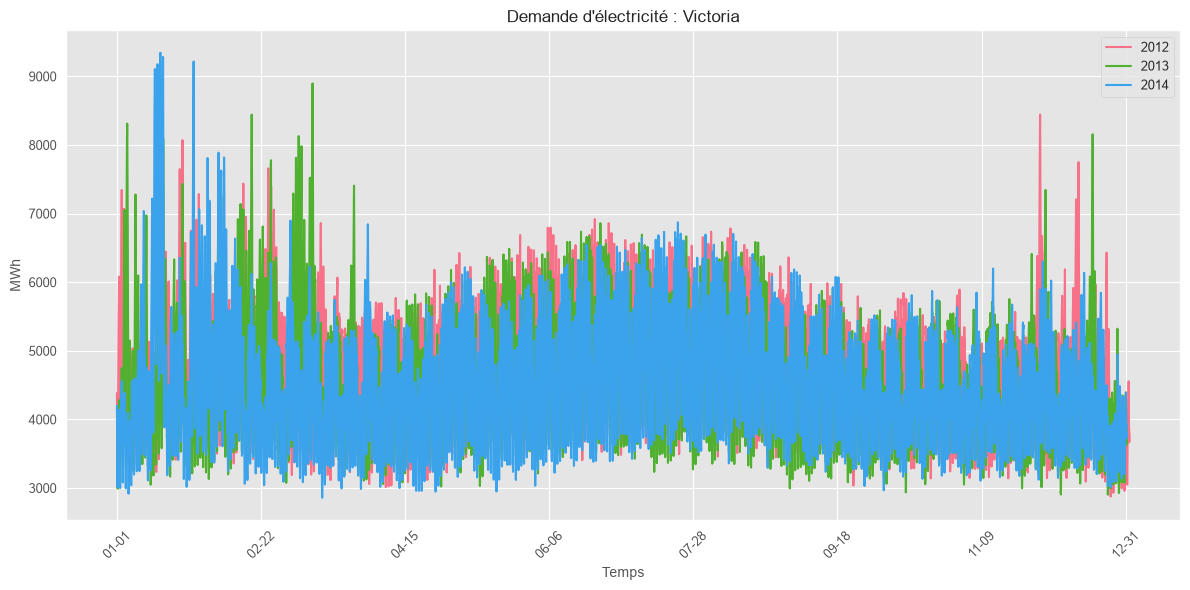

In [36]:
df = vic_elec_demand.assign(
    jour_annee=lambda x: x["ds"].dt.strftime("%m-%d"),
    annee=lambda x: x["ds"].dt.year,
)

palette = sns.color_palette(
    "husl",
    n_colors=df["annee"].nunique()
)

fig, ax = plt.subplots(figsize=(12, 6))

for i_annee, (annee, df_annee) in enumerate(df.groupby("annee")):
    df_annee.plot(
        x="jour_annee",
        y="y",
        ax=ax,
        label=str(annee),
        color=palette[i_annee]
    )

ax.set(
    title="Demande d'électricité : Victoria",
    ylabel="MWh",
    xlabel="Temps",
)

plt.xticks(rotation=45)

fig.tight_layout()

 Graphique saisonnier montrant les tendances saisonnières annuelles de la demande d’électricité en Victoria

## Graphiques des sous-séries saisonnières

Un autre type de graphique permettant de mettre en évidence les schémas saisonniers consiste à regrouper les données de chaque saison dans des **mini-graphiques temporels distincts**.

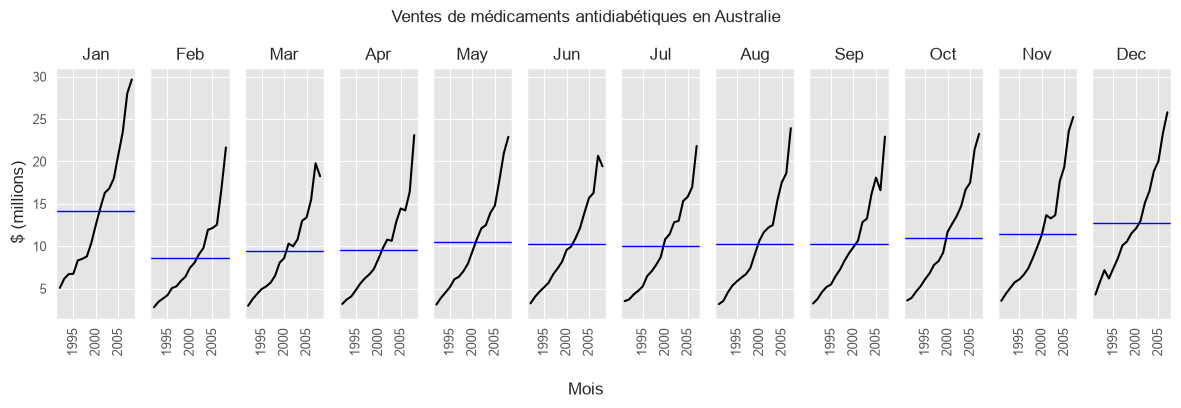

In [37]:
df = total_cost_df.assign(
    annee=total_cost_df["Month"].dt.year,
    nom_mois=total_cost_df["Month"].dt.month_name(),
    mois_idx=total_cost_df["Month"].dt.month,
)

fig, axes = plt.subplots(
    1, 12,
    figsize=(12, 4),
    sharey=True
)

for ax, ((_, nom_mois), df_mois) in zip(
    axes,
    df.groupby(["mois_idx", "nom_mois"])
):
    cout_moyen = df_mois["Cost"].mean()

    ax.plot(
        df_mois["annee"],
        df_mois["Cost"],
        color="k"
    )

    ax.axhline(
        cout_moyen,
        color="b",
        linewidth=1
    )

    ax.set(
        title=nom_mois[:3],
        xlabel=""
    )

    ax.tick_params(
        axis="x",
        rotation=90
    )

fig.suptitle(
    "Ventes de médicaments antidiabétiques en Australie"
)

fig.supxlabel("Mois")
fig.supylabel("$ (millions)")

fig.tight_layout()

 Graphique des sous-séries saisonnières des ventes mensuelles de médicaments antidiabétiques en Australie

Les lignes horizontales indiquent les **moyennes pour chaque mois**. Ce type de graphique permet de visualiser clairement le **schéma saisonnier sous-jacent** et de mettre en évidence les changements de saisonnalité au fil du temps.

Il est particulièrement utile pour identifier les évolutions au sein de certaines saisons ou de certains mois. Dans cet exemple, le graphique n’est pas particulièrement révélateur. Cependant, dans certains cas, il constitue la méthode la plus utile pour observer les **changements saisonniers au fil du temps**.

### Exemple : tourisme de vacances australien

Les données trimestrielles sur le tourisme de vacances en Australie offrent un exemple intéressant de la manière dont ces graphiques peuvent révéler des informations utiles.

Tout d’abord, nous devons extraire les données pertinentes du `DataFrame`. Toutes les fonctions habituelles de manipulation des données de Pandas peuvent être utilisées.

Pour obtenir le **nombre total de nuitées de visiteurs en vacances par État et pour chaque trimestre**, en ignorant les régions, nous pouvons utiliser le code suivant.

In [39]:
tourism = pd.read_csv("data/tourism.csv", parse_dates=["ds"])
trips = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .groupby(["State", "ds"], as_index=False)
    .agg({"y": "sum"})
)
trips.head()

,State,ds,y
0,ACT,1998-01-01,196.219
1,ACT,1998-04-01,126.771
2,ACT,1998-07-01,110.680
3,ACT,1998-10-01,170.472
4,ACT,1999-01-01,107.779


Les graphiques temporels de chaque série montrent qu’il y a une forte saisonnalité dans la plupart des États, mais que les pics saisonniers ne coïncident pas.

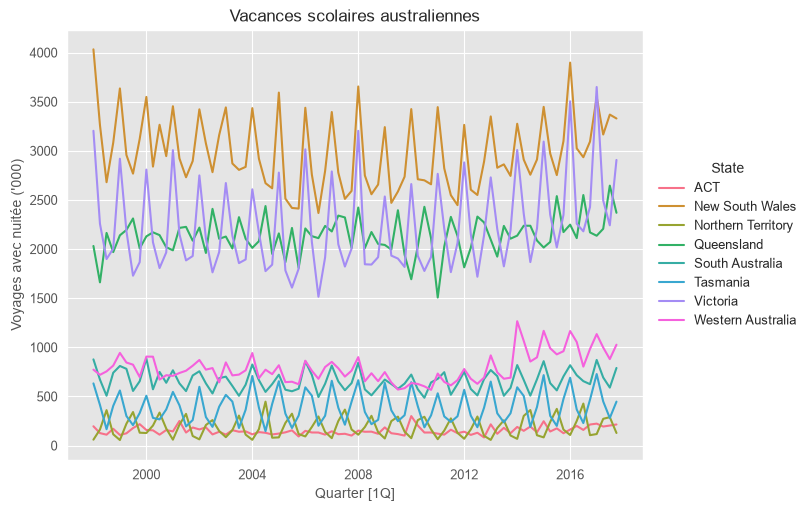

In [42]:
fig, ax = plt.subplots()
palette = sns.color_palette("husl", trips["State"].nunique())
sns.lineplot(data=trips, x="ds", y="y", hue="State", palette=palette)
ax.set(
    title="Vacances scolaires australiennes",
    ylabel="Voyages avec nuitée ('000)",
    xlabel="Quarter [1Q]",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0, title="State")
fig.show()

Graphiques temporels des jours fériés nationaux australiens par Éta

Pour observer les périodes de **pics saisonniers** dans chaque État, nous pouvons utiliser un **graphique saisonnier**.

Ce graphique montre clairement que les États du sud de l’Australie, notamment la **Tasmanie, Victoria et l’Australie-Méridionale**, connaissent leur niveau de tourisme le plus élevé au **premier trimestre**, qui correspond à leur saison estivale.

À l’inverse, les États du nord, notamment le **Queensland et le Territoire du Nord**, enregistrent leur niveau de tourisme le plus élevé au **troisième trimestre**, qui correspond à leur saison sèche.

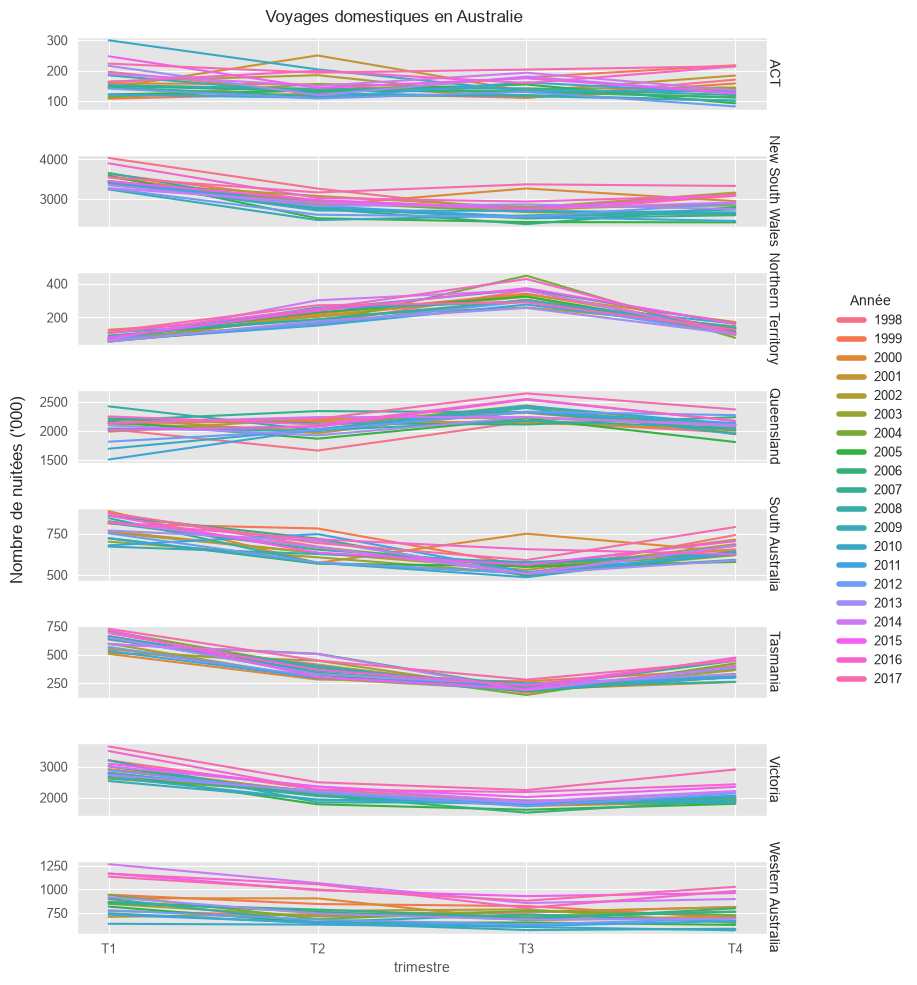

In [43]:
df = trips.assign(
    trimestre="T" + trips["ds"].dt.quarter.astype("string"),
    annee=trips["ds"].dt.year,
)

# Nombre d'États et d'années
num_etats, num_annees = df[["State", "annee"]].nunique()

# Palette de couleurs
palette = sns.color_palette("husl", num_annees)

# Création des graphiques
fig, axes = plt.subplots(
    num_etats,
    sharex=True,
    figsize=(8, 10)
)

# Un graphique par État
for ax, (etat, df_etat) in zip(
    axes,
    df.groupby("State")
):
    sns.lineplot(
        data=df_etat,
        x="trimestre",
        y="y",
        hue="annee",
        palette=palette,
        ax=ax
    )

    # Supprimer la légende individuelle
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set(ylabel="")

    # Nom de l'État
    ax.text(
        1.02,
        0.5,
        etat,
        va="center",
        ha="right",
        rotation=270,
        size="medium",
        transform=ax.transAxes
    )

# Récupérer les éléments de légende
handles, labels = ax.get_legend_handles_labels()

for h in handles:
    h.set_linewidth(4)

# Légende générale
fig.legend(
    handles,
    labels,
    title="Année",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False,
    borderaxespad=0
)

fig.suptitle("Voyages domestiques en Australie")
fig.supylabel("Nombre de nuitées ('000)")

fig.tight_layout()

Graphique saisonnier des vacances domestiques australiennes par État

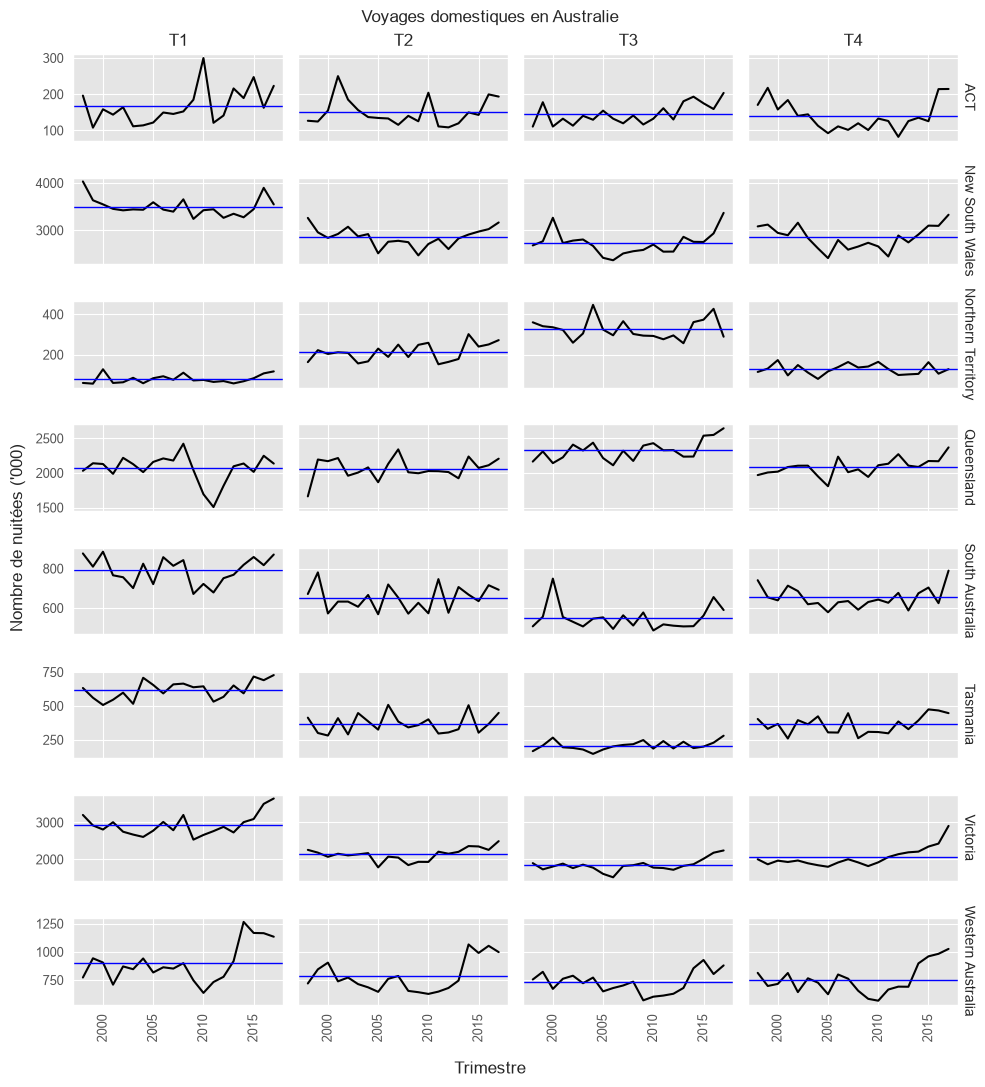

In [44]:
fig, axes = plt.subplots(
    num_etats,
    4,
    sharex=True,
    sharey="row",
    figsize=(10, 11)
)

for ax, ((etat, trimestre), df_et) in zip(
    axes.flat,
    df.groupby(["State", "trimestre"])
):
    ax.plot(
        df_et["annee"],
        df_et["y"],
        color="k"
    )

    # Moyenne du trimestre
    ax.axhline(
        df_et["y"].mean(),
        color="b",
        linewidth=1
    )

    ax.tick_params(
        axis="x",
        rotation=90
    )

    # Afficher uniquement les années multiples de 5
    xticks = df_et["annee"].loc[
        lambda x: (x % 5) == 0
    ]

    # Titres des colonnes
    if ax in axes[0]:
        ax.set(
            title=trimestre,
            xticks=xticks
        )

    # Nom de l'État à droite
    if ax in axes[:, -1]:
        ax.text(
            1.02,
            0.5,
            etat,
            va="center",
            ha="left",
            rotation=270,
            size="medium",
            transform=ax.transAxes
        )

fig.suptitle(
    "Voyages domestiques en Australie"
)

fig.supxlabel(
    "Trimestre"
)

fig.supylabel(
    "Nombre de nuitées ('000)"
)

fig.tight_layout()

 Graphique des sous-séries saisonnières des vacances domestiques australiennes par État

Les graphiques de sous-séries correspondants permettent d’observer plus précisément l’évolution du tourisme dans chaque État.

Ils montrent notamment que le **tourisme en Australie-Occidentale** a fortement augmenté au cours des dernières années. En **Victoria**, le tourisme a augmenté au **premier et au quatrième trimestre**, mais cette progression est moins marquée au milieu de l’année.

## Diagrammes de points

Les graphiques présentés jusqu’à présent sont utiles pour visualiser des séries temporelles individuelles. Il est également intéressant d’explorer les **relations entre plusieurs séries temporelles**.

Les données présentent deux séries temporelles : la **demande d’électricité toutes les demi-heures**, mesurée en gigawatts (GW), et la **température**, mesurée en degrés Celsius (°C), pour l’année 2014 dans l’État de Victoria, en Australie.

Les températures sont celles de **Melbourne**, la plus grande ville de Victoria, tandis que les données de demande d’électricité concernent **l’ensemble de l’État**.


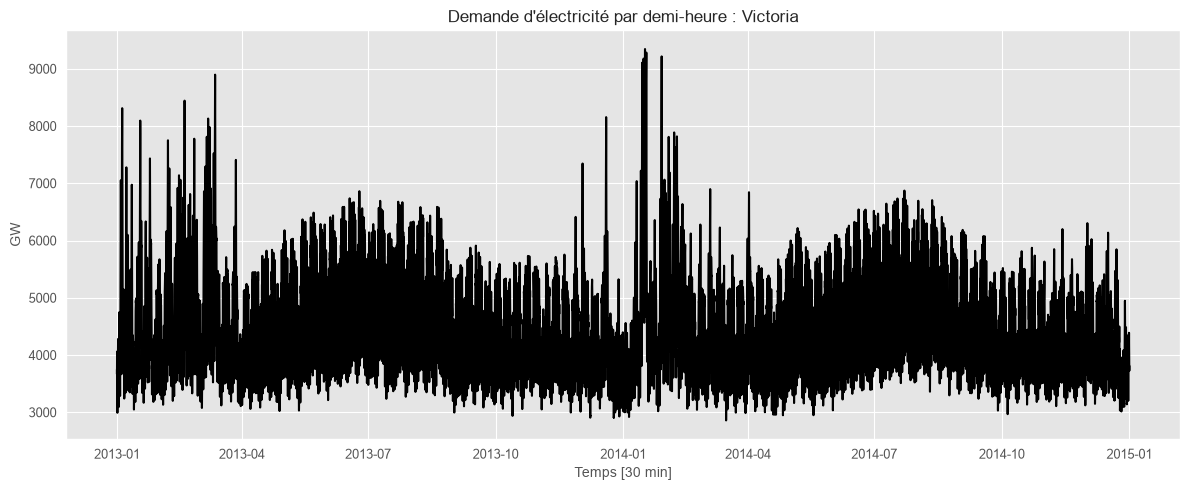

In [45]:
df = vic_elec_df[vic_elec_df["unique_id"] == "Demand"].copy()

# Garder environ les 2 dernières années
df = df.tail(2 * 24 * 365 * 2)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df["ds"],
    df["y"]
)

ax.set(
    title="Demande d'électricité par demi-heure : Victoria",
    xlabel="Temps [30 min]",
    ylabel="GW"
)

ax.grid(True)
fig.tight_layout()


Demande d’électricité toutes les demi-heures à Victoria, Australie, pour 2014.

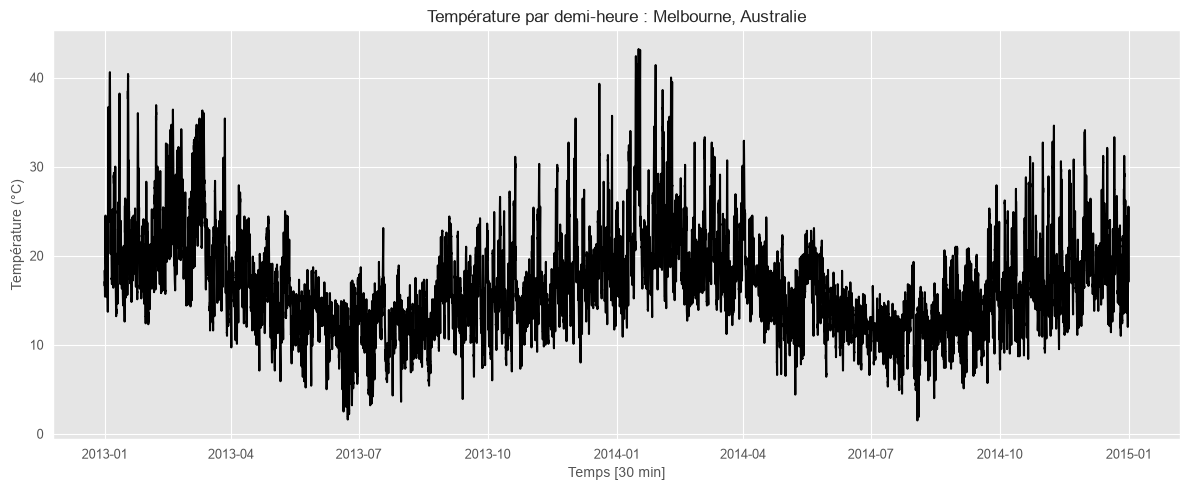

In [46]:
df = vic_elec_df[
    vic_elec_df["unique_id"] == "Temperature"
].tail(2 * 48 * 365)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df["ds"],
    df["y"]
)

ax.set(
    title="Température par demi-heure : Melbourne, Australie",
    xlabel="Temps [30 min]",
    ylabel="Température (°C)"
)

ax.grid(True)
fig.tight_layout()

Température toutes les demi-heures à Melbourne, Australie, pour 2014

Nous pouvons étudier la relation entre la demande et la température en représentant une série contre l’autre

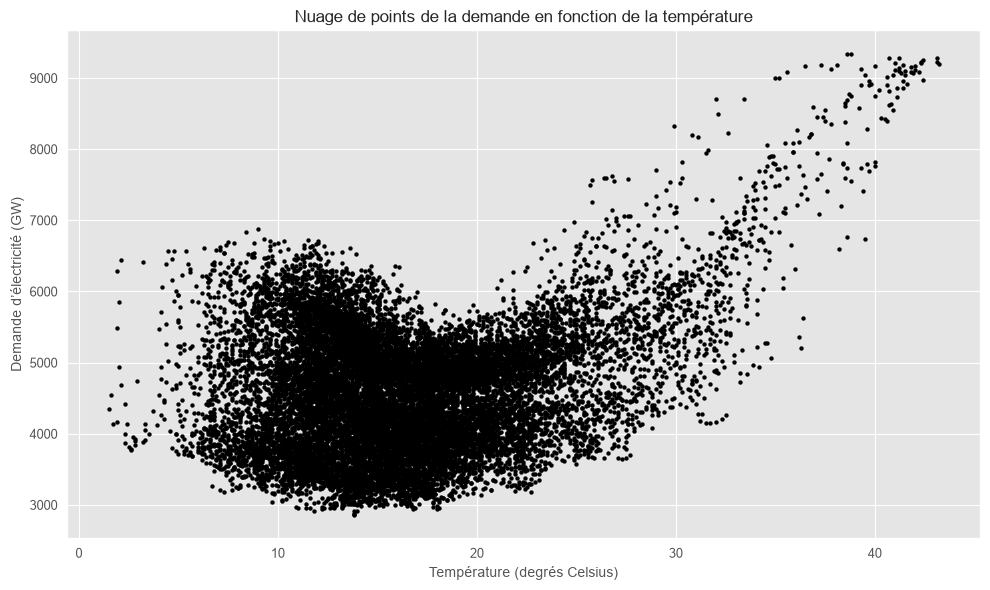

In [47]:
elec_2014 = (
    vic_elec_df
    .loc[lambda x: x["ds"].dt.year == 2014]
    .pivot(index="ds", columns="unique_id", values="y")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=elec_2014,
    x="Temperature",
    y="Demand",
    ax=ax,
    linewidth=0,
    s=10,
    legend=False
)

ax.set(
    title="Nuage de points de la demande en fonction de la température",
    xlabel="Température (degrés Celsius)",
    ylabel="Demande d’électricité (GW)"
)

plt.tight_layout()
plt.show()

La demande d’électricité toutes les demi-heures est présentée par rapport à la température pour 2014 dans le Victoria, Australie

Ce nuage de points nous aide à visualiser la relation entre les variables. Il est clair que la forte demande survient lorsque les températures sont élevées en raison de l’effet de la climatisation. Mais il existe aussi un effet de chauffage, où la demande augmente pour les basses températures.

### Corrélation

Il est courant de calculer des **coefficients de corrélation** afin de mesurer la force de la relation linéaire entre deux variables.

La corrélation entre les variables `x` et `y` est donnée par :

$$
r =
\frac{\sum_t (x_t-\bar{x})(y_t-\bar{y})}
{\sqrt{\sum_t (x_t-\bar{x})^2}\sqrt{\sum_t (y_t-\bar{y})^2}}
$$

La valeur de `r` est toujours comprise entre **−1 et 1** :

- `r = 1` : relation linéaire positive parfaite ;
- `r = -1` : relation linéaire négative parfaite ;
- `r ≈ 0` : absence de relation linéaire.

Ainsi, les valeurs négatives indiquent une **relation négative**, tandis que les valeurs positives indiquent une **relation positive**.

Les graphiques présentés illustrent des exemples de jeux de données présentant différents niveaux de corrélation.

### Matrices de nuages de points

Lorsqu’il existe plusieurs **variables prédictives potentielles**, il peut être utile de représenter chaque variable en fonction des autres afin d’étudier leurs relations.

Considérons les **huit séries temporelles** représentant le nombre trimestriel de visiteurs dans les différents États et territoires d’Australie.

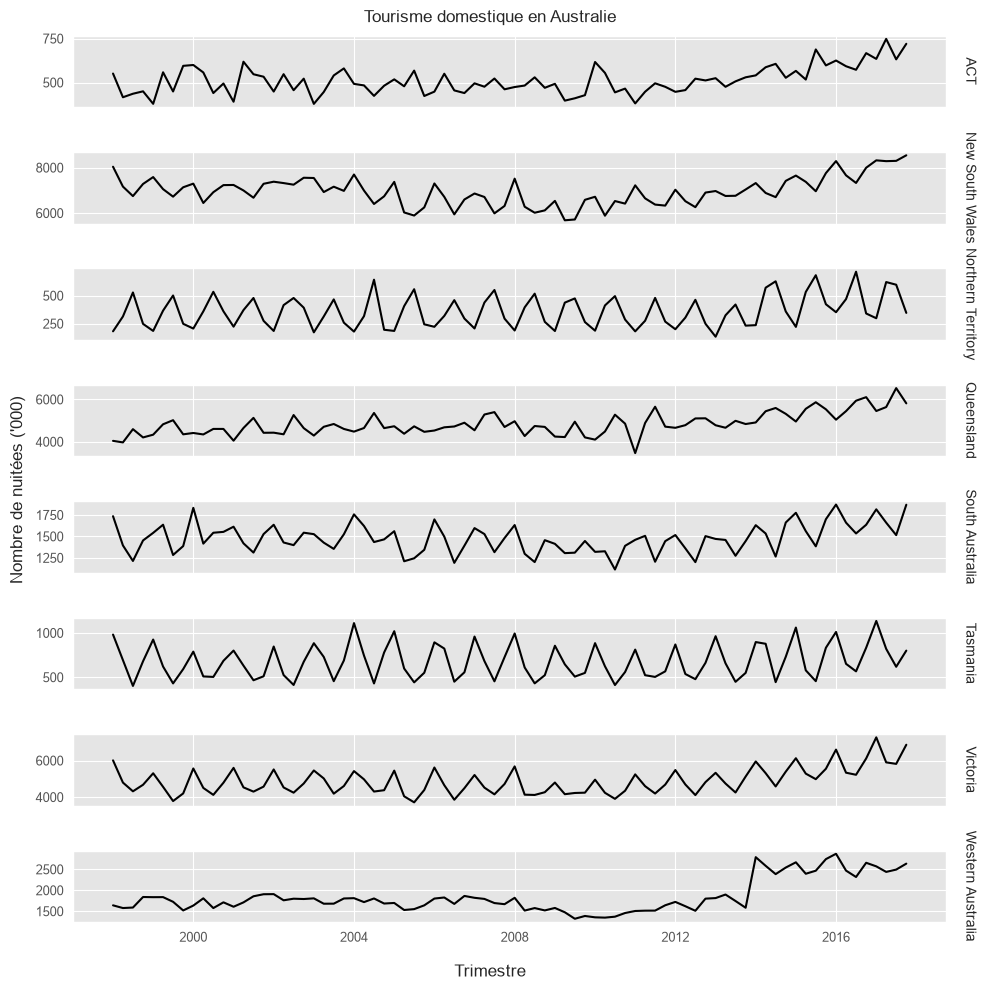

In [48]:
# Agrégation du nombre de visiteurs par État et par trimestre
visiteurs = (
    tourism
    .groupby(["State", "ds"], as_index=False)["y"]
    .sum()
)

# Nombre d'États
num_etats = visiteurs["State"].nunique()

# Création des graphiques
fig, axes = plt.subplots(
    num_etats,
    1,
    sharex=True,
    figsize=(10, 10)
)

# Un graphique par État
for ax, (etat, df_etat) in zip(
    axes,
    visiteurs.groupby("State")
):
    ax.plot(
        df_etat["ds"],
        df_etat["y"]
    )

    ax.text(
        1.02,
        0.5,
        etat,
        va="center",
        ha="left",
        rotation=270,
        transform=ax.transAxes
    )

fig.suptitle(
    "Tourisme domestique en Australie"
)

fig.supxlabel(
    "Trimestre"
)

fig.supylabel(
    "Nombre de nuitées ('000)"
)

fig.tight_layout()


Nuits trimestrielles des visiteurs pour les États et territoires d’Australie

Pour analyser les relations entre ces huit séries temporelles, nous pouvons comparer chaque série avec les autres.

Ces différents graphiques peuvent être organisés sous la forme d’une **matrice de nuages de points**, ce qui permet de visualiser simultanément les relations entre toutes les paires de séries temporelles.

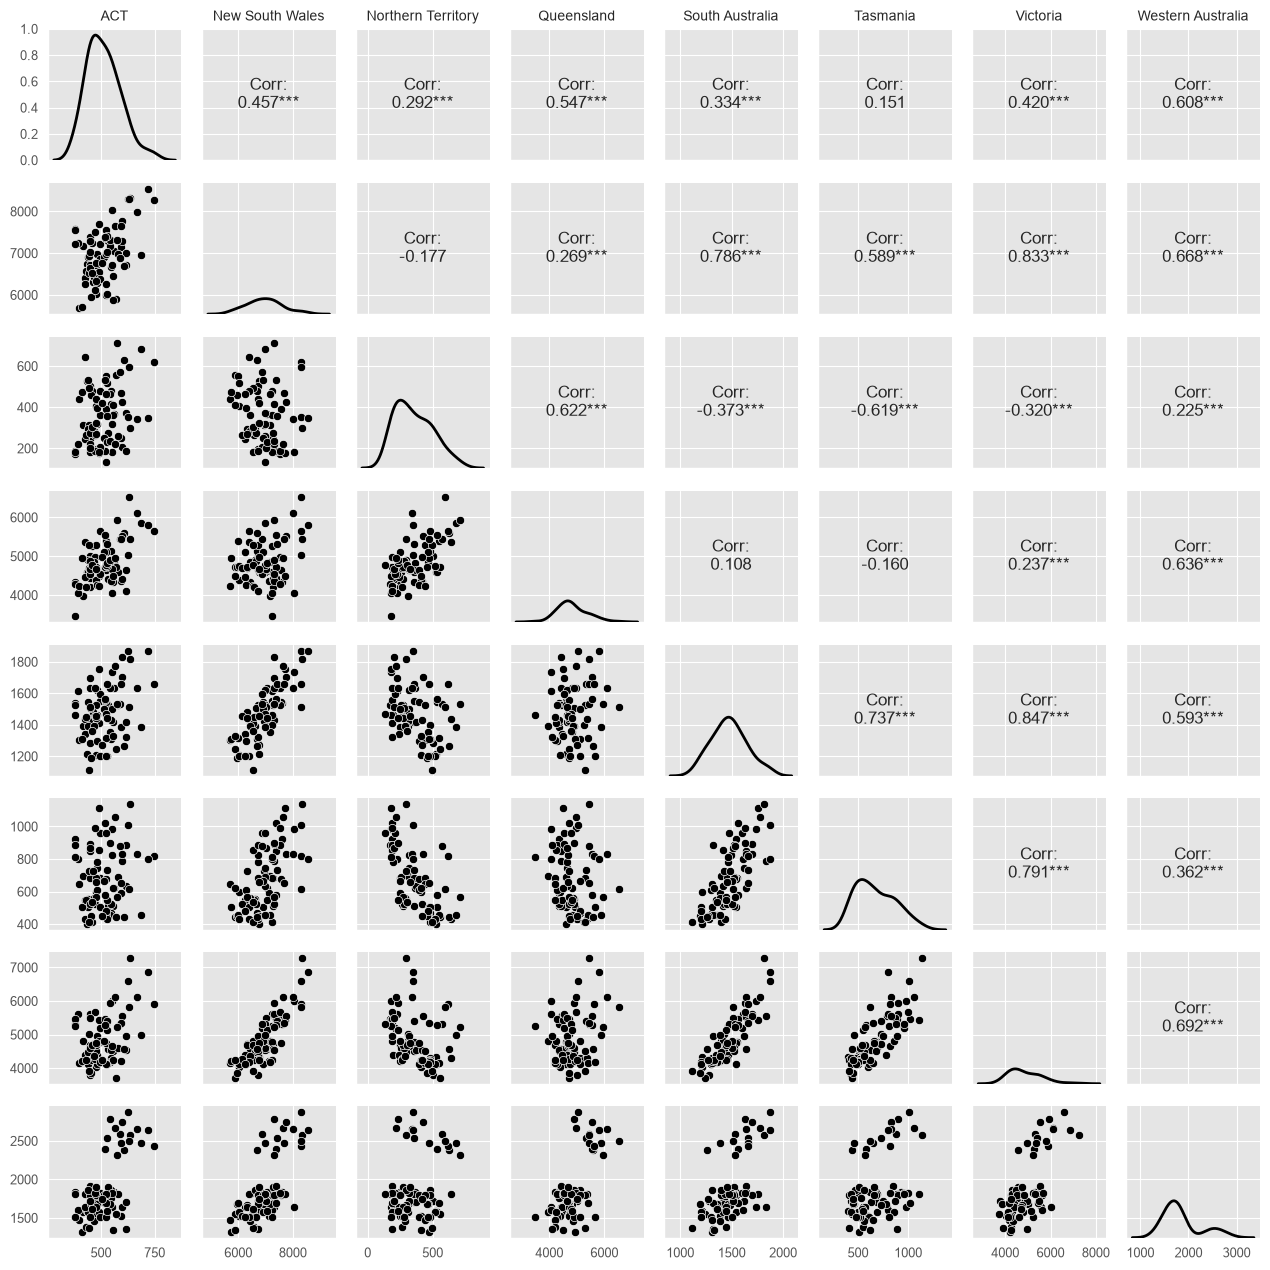

In [50]:
df = visiteurs.pivot(
    index="ds",
    columns="State",
    values="y"
)

def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)

    ax = plt.gca()

    ax.annotate(
        f"Corr:\n{r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=12
    )

g = sns.PairGrid(df, height=1.6)

g.map_lower(sns.scatterplot)
g.map_upper(corrfunc)
g.map_diag(sns.kdeplot, lw=2)

g.set(xlabel="", ylabel="")

for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size="medium")

plt.tight_layout()
plt.show()

Une matrice de nuits de visiteurs trimestrielles dans les États et territoires d’Australie

Pour chaque case de la matrice, la variable représentée sur l’axe vertical correspond au **nom de la variable indiqué sur la ligne**, tandis que la variable représentée sur l’axe horizontal correspond au **nom de la variable indiqué sur la colonne**.

Il existe plusieurs options permettant de choisir le type de graphique affiché dans chaque panneau. Dans la configuration par défaut :

- les **coefficients de corrélation** sont affichés dans la partie supérieure droite ;
- les **nuages de points** sont affichés dans la partie inférieure ;
- les **graphiques de densité** sont affichés sur la diagonale.

L’intérêt d’une matrice de nuages de points est de fournir une **vue d’ensemble rapide des relations entre toutes les paires de variables**.

Dans cet exemple, on observe principalement des **relations positives**. Les relations les plus fortes apparaissent entre les États voisins situés sur la côte sud et sud-est de l’Australie, notamment la **Nouvelle-Galles du Sud, Victoria et l’Australie-Méridionale**.

Certaines relations négatives apparaissent également entre le **Territoire du Nord** et les autres régions. Le Territoire du Nord, situé dans le nord de l’Australie et connu pour ses paysages désertiques de l’outback, attire principalement les visiteurs pendant l’hiver.

Ainsi, le **pic de fréquentation du Territoire du Nord** se situe autour du trimestre de juillet, correspondant à l’hiver, contrairement aux autres régions où le pic de fréquentation se situe généralement autour du trimestre de janvier, correspondant à l’été.

## Graphiques de Latence

Les **graphiques de Latence** permettent d’étudier la relation entre les valeurs actuelles et les valeurs passées d’une série temporelle.

Ils présentent des **nuages de points** de la production trimestrielle de bière australienne. L’axe horizontal représente les valeurs retardées de la série temporelle.

Chaque graphique compare donc `y_t` avec `y_{t-k}`, pour différentes valeurs de `k`, où `k` représente le **nombre de périodes de retard**.

Autrement dit :

- `k = 1` : comparaison entre `y_t` et `y_{t-1}` ;
- `k = 2` : comparaison entre `y_t` et `y_{t-2}` ;
- `k = 4` : comparaison entre `y_t` et `y_{t-4}`.

Ces graphiques permettent notamment d’identifier des **relations temporelles**, des **dépendances entre observations successives** et d’éventuels **schémas saisonniers**.

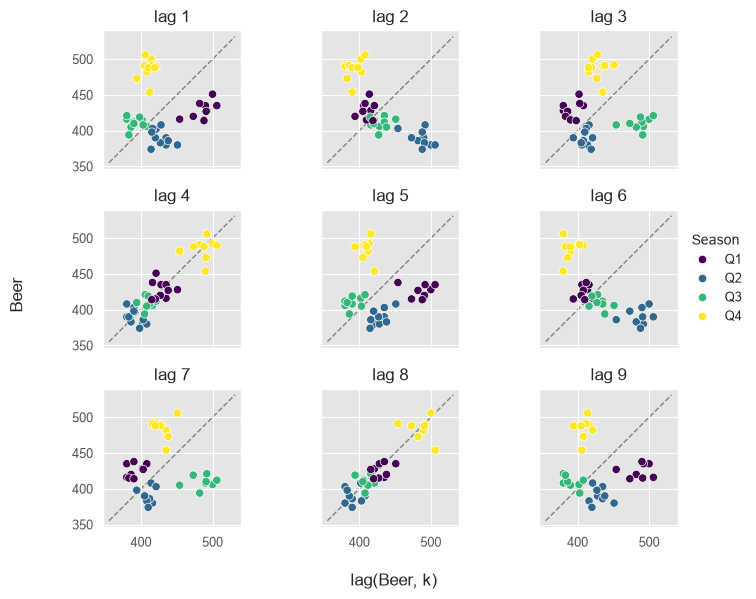

In [51]:
beer = (
    pd.read_csv("data/aus_production.csv", parse_dates=["ds"])
    [["ds", "Beer"]]
    .loc[lambda x: x["ds"] >= "2000"]
    .assign(
        Season=lambda x: "Q" + x["ds"].dt.quarter.astype("string")
    )
    .rename(columns={"Beer": "y"})
)

# Limites des axes
lims = (
    0.95 * beer["y"].min(),
    1.05 * beer["y"].max()
)

# Palette de couleurs
cmap = plt.get_cmap("viridis")

colors = {
    season: cmap(i / 3)
    for i, season in enumerate(beer["Season"].unique())
}

# Création des graphiques
fig, axes = plt.subplots(
    3, 3,
    figsize=(8, 6),
    sharex=True,
    sharey=True
)

for i, ax in enumerate(axes.flat):

    lag = i + 1

    df = beer.assign(
        lag=beer["y"].shift(lag)
    )

    sns.scatterplot(
        data=df,
        x="lag",
        y="y",
        hue="Season",
        palette=colors,
        ax=ax
    )

    # Ligne y = x
    ax.plot(
        lims,
        lims,
        color=".5",
        ls="--",
        lw=1,
        zorder=-1
    )

    ax.set(
        title=f"lag {lag}",
        xlabel="",
        ylabel="",
        aspect="equal"
    )

    # Supprimer les légendes individuelles
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Légende commune
axes[1, -1].legend(
    loc="center left",
    title="Season",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False,
    borderaxespad=0
)

fig.supxlabel("lag(Beer, k)")
fig.supylabel("Beer")

plt.tight_layout()

# Affichage
plt.show()

 Diagrammes de points retardés pour la production trimestrielle de bière

Dans ces graphiques, les **couleurs indiquent le trimestre de la variable représentée sur l’axe vertical**.

On observe une **forte relation positive** aux retards `4` et `8`, ce qui reflète la forte **saisonnalité trimestrielle** des données.

La **relation négative** observée aux retards `2` et `6` s’explique par le fait que les **pics de production**, généralement observés au quatrième trimestre (Q4), sont comparés aux **creux de production**, généralement observés au deuxième trimestre (Q2).

Ainsi, les graphiques de retard permettent de mettre en évidence la **structure saisonnière** et les dépendances entre les observations séparées par plusieurs périodes.

## Autocorrélation

Tout comme la **corrélation** mesure l’intensité d’une relation linéaire entre deux variables, l’**autocorrélation** mesure la relation linéaire entre les **valeurs retardées d’une même série temporelle**.

Il existe plusieurs coefficients d’autocorrélation, correspondant aux différents retards représentés dans un graphique de retard. Par exemple :

- `r₁` mesure la relation entre `yₜ` et `yₜ₋₁` ;
- `r₂` mesure la relation entre `yₜ` et `yₜ₋₂` ;
- et ainsi de suite.

La valeur de `rₖ` peut s’écrire :

$$
r_k =
\frac{
\sum_{t=k+1}^{T}(y_t-\bar{y})(y_{t-k}-\bar{y})
}{
\sum_{t=1}^{T}(y_t-\bar{y})^2
}
$$

où `T` représente la longueur de la série temporelle.

L’ensemble des coefficients d’autocorrélation constitue la **fonction d’autocorrélation**, généralement appelée **ACF** (*Autocorrelation Function*).

Les coefficients d’autocorrélation des données de production de bière peuvent être calculés à l’aide de la fonction `acf()`.

In [53]:
acf = sm.tsa.acf(beer["y"], nlags=9, fft=False, bartlett_confint=False)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")
acf_df[1:].T

lag,1,2,3,4,5,6,7,8,9
ACF,-0.053,-0.758,-0.026,0.802,-0.077,-0.657,0.001,0.707,-0.089


Les valeurs de la colonne `ACF` sont notées `r₁, …, r₉` et correspondent aux neuf nuages de points présentés précédemment.

Nous représentons généralement l’**ACF** sous forme de graphique afin d’observer comment les coefficients d’autocorrélation évoluent en fonction du **retard `k`**.

Ce type de graphique est parfois appelé **corrélogramme**.

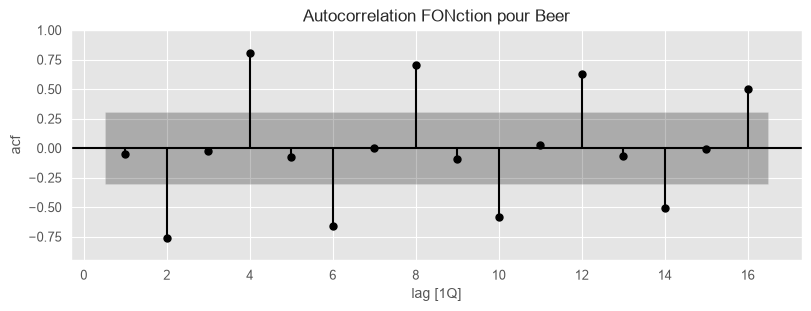

In [55]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(beer["y"], lags=16, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation FONction pour Beer",
    xlabel="lag [1Q]", ylabel="acf",
)
fig.show()

 Fonction d’autocorrélation pour la production trimestrielle de bière

On observe que :

- `r₄` est plus élevé que les autres coefficients de retard. Cela s’explique par le **schéma saisonnier** des données : les pics ont tendance à être séparés de quatre trimestres, tout comme les creux.
- `r₂` est plus négatif que les autres coefficients de retard, car les creux ont tendance à se situer deux trimestres après les pics.
- Les **zones ombrées en gris** indiquent si les coefficients de corrélation sont significativement différents de zéro, comme expliqué dans la section consacrée au **bruit blanc**.

### Tendance et saisonnalité dans les graphiques ACF

Lorsque les données présentent une **tendance**, les autocorrélations pour les petits retards ont tendance à être importantes et positives, car les observations proches dans le temps ont également tendance à avoir des valeurs proches. Ainsi, l’ACF d’une série temporelle présentant une tendance tend à afficher des valeurs positives qui **diminuent progressivement** à mesure que les retards augmentent.

Lorsque les données présentent une **saisonnalité**, les autocorrélations sont généralement plus importantes pour les **retards saisonniers**, c’est-à-dire pour les multiples de la période saisonnière, que pour les autres retards.

Lorsque les données présentent à la fois une **tendance et une saisonnalité**, on observe une combinaison de ces deux effets.

Les données de `total_cost_df` présentent à la fois une tendance et une saisonnalité. Son ACF permet d’observer ces deux caractéristiques :

- la **diminution progressive de l’ACF** lorsque les retards augmentent est principalement due à la tendance ;
- la forme en **« festons »** de l’ACF est due à la saisonnalité.

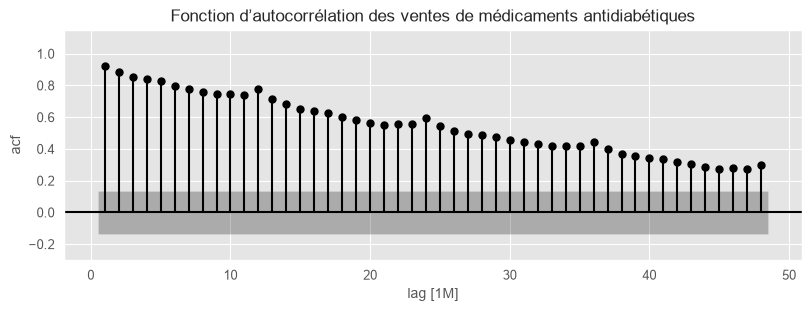

In [57]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(total_cost_df["Cost"], lags=48, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Fonction d’autocorrélation des ventes de médicaments antidiabétiques",
    xlabel="lag [1M]", ylabel="acf", ylim=(-0.3, None),
)
fig.show()

Fonction d’autocorrélation pour les ventes mensuelles de médicaments antidiabétiques en Australie.

## Bruit blanc

Les séries temporelles qui ne présentent **aucune autocorrélation** sont appelées **bruit blanc**.

Une série de bruit blanc ne présente donc ni **tendance**, ni **saisonnalité**, ni **structure temporelle identifiable**. Les observations sont essentiellement imprévisibles à partir de leurs valeurs passées.

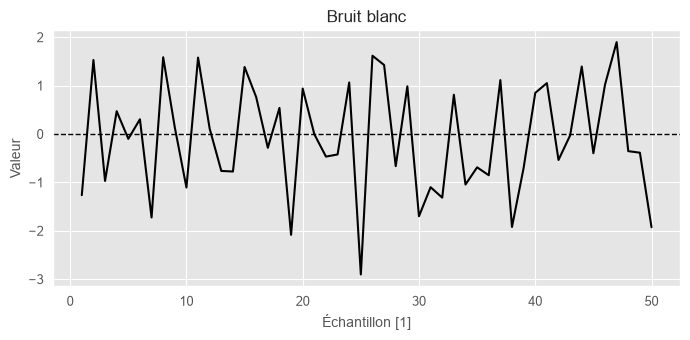

In [59]:
plt.rcParams["figure.figsize"] = [7, 3.5]

random = np.random.RandomState(30)

wn = pd.DataFrame({
    "y": random.normal(0, 1, 50),
    "ds": np.arange(1, 51),
    "unique_id": "wn",
})

# Visualisation du bruit blanc
fig, ax = plt.subplots()

ax.plot(wn["ds"], wn["y"])

ax.set(
    xlabel="Échantillon [1]",
    ylabel="Valeur",
    title="Bruit blanc"
)

ax.axhline(0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

Série de bruit blanc.

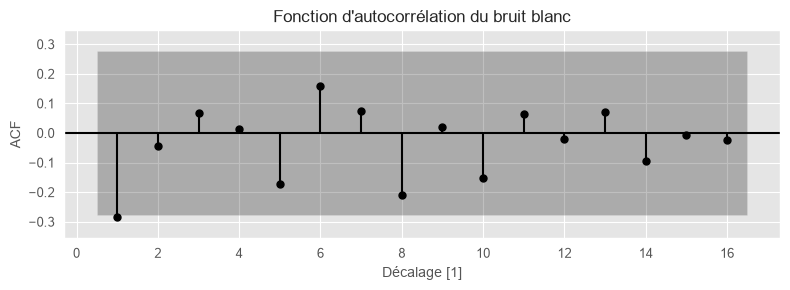

In [60]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_acf(
    wn["y"],
    lags=16,
    ax=ax,
    zero=False,
    bartlett_confint=False,
    auto_ylims=True
)

ax.set(
    title="Fonction d'autocorrélation du bruit blanc",
    xlabel="Décalage [1]",
    ylabel="ACF"
)

plt.tight_layout()
plt.show()

Pour une série de **bruit blanc**, on s’attend à ce que chaque coefficient d’autocorrélation soit proche de zéro. Ils ne sont toutefois pas nécessairement exactement égaux à zéro en raison des **variations aléatoires**.

Pour une série de bruit blanc, environ **95 % des coefficients d’autocorrélation** devraient se situer dans les limites :

$$
\pm \frac{1.96}{\sqrt{T}}
$$

où `T` représente la longueur de la série temporelle.

Il est courant de représenter ces limites sur le graphique de l’ACF. Si un ou plusieurs pics importants dépassent ces limites, ou si beaucoup plus de 5 % des pics se trouvent en dehors de celles-ci, la série n’est probablement **pas un bruit blanc**.

Dans cet exemple, `T = 50`. Les limites sont donc :

$$
\pm \frac{1.96}{\sqrt{50}} \approx \pm 0.28
$$

Tous les coefficients d’autocorrélation, à l’exception du premier, se situent dans ces limites. Ils ne dépassent que légèrement les bornes attendues, ce qui confirme que les données sont compatibles avec un **bruit blanc**.